# Fake News Detector

## Installing Necessary Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import string
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

## Loading the data

In [ ]:
df = pd.read_csv('/Users/alokmalla/Documents/Applied_ML/PROJECT/alok_AMLproject/data/new_class_dataset.csv')


In [5]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [6]:
data_fake=df[df['label']==0]
data_true=df[df['label']==1]

### Data Preview

In [7]:
data_fake.head()

,Unnamed: 0,title,text,label
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
11,11,"May Brexit offer would hurt, cost EU citizens ...",BRUSSELS (Reuters) - British Prime Minister Th...,0
12,12,Schumer calls on Trump to appoint official to ...,"WASHINGTON (Reuters) - Charles Schumer, the to...",0
14,14,No Change Expected for ESPN Political Agenda D...,As more and more sports fans turn off ESPN to ...,0
15,15,Billionaire Odebrecht in Brazil scandal releas...,RIO DE JANEIRO/SAO PAULO (Reuters) - Billionai...,0


In [8]:
data_true.tail()

,Unnamed: 0,title,text,label
72125,72125,WOW! JILL STEIN’S ‘FIRESIDE CHAT’ Exposes Her ...,,1
72127,72127,WIKILEAKS EMAIL SHOWS CLINTON FOUNDATION FUNDS...,An email released by WikiLeaks on Sunday appea...,1
72128,72128,JUDGE JEANINE SOUNDS FREE SPEECH ALARM: “They ...,Judge Jeanine lets it rip! She s concerned wit...,1
72130,72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1
72133,72133,Goldman Sachs Endorses Hillary Clinton For Pre...,Goldman Sachs Endorses Hillary Clinton For Pre...,1


In [9]:
data_fake["class"]=0
data_true['class']=1

<ipython-input-9-868bd1bd527b>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_fake["class"]=0
<ipython-input-9-868bd1bd527b>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_true['class']=1


In [10]:
data_fake.drop(['Unnamed: 0', 'label'], axis = 1, inplace = True)
data_true.drop(['Unnamed: 0', 'label'], axis = 1, inplace = True)

<ipython-input-10-1f60a7f0dbce>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_fake.drop(['Unnamed: 0', 'label'], axis = 1, inplace = True)
<ipython-input-10-1f60a7f0dbce>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_true.drop(['Unnamed: 0', 'label'], axis = 1, inplace = True)


In [11]:
data_fake.head()

,title,text,class
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
11,"May Brexit offer would hurt, cost EU citizens ...",BRUSSELS (Reuters) - British Prime Minister Th...,0
12,Schumer calls on Trump to appoint official to ...,"WASHINGTON (Reuters) - Charles Schumer, the to...",0
14,No Change Expected for ESPN Political Agenda D...,As more and more sports fans turn off ESPN to ...,0
15,Billionaire Odebrecht in Brazil scandal releas...,RIO DE JANEIRO/SAO PAULO (Reuters) - Billionai...,0


In [12]:
data_fake.shape, data_true.shape

((35028, 3), (37106, 3))

In [13]:
data_merge=pd.concat([data_fake, data_true], axis = 0)
data_merge.head(10)

,title,text,class
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
11,"May Brexit offer would hurt, cost EU citizens ...",BRUSSELS (Reuters) - British Prime Minister Th...,0
12,Schumer calls on Trump to appoint official to ...,"WASHINGTON (Reuters) - Charles Schumer, the to...",0
14,No Change Expected for ESPN Political Agenda D...,As more and more sports fans turn off ESPN to ...,0
15,Billionaire Odebrecht in Brazil scandal releas...,RIO DE JANEIRO/SAO PAULO (Reuters) - Billionai...,0
17,U.N. seeks humanitarian pause in Sanaa where s...,GENEVA (Reuters) - The United Nations called o...,0
19,Second judge says Clinton email setup may have...,NEW YORK (Reuters) - A second federal judge ha...,0
26,Supreme Court Won’t Hear Appeal From Texas on ...,WASHINGTON — The Supreme Court rejected on ...,0
27,Islamic State driven out of last stronghold in...,BAGHDAD (Reuters) - Iraqi forces announced on ...,0
28,Senators Propose Giving States Option to Keep ...,WASHINGTON — Several Republican senators on...,0


#### "title",  "subject" and "date" columns is not required for detecting the fake news, so I am going to drop the columns.

In [14]:
data_merge.columns

Index(['title', 'text', 'class'], dtype='object')

In [15]:
data=data_merge.drop(['title'], axis = 1)

In [ ]:

data.isnull().sum()

,0
text,39
class,0


In [ ]:

data = data.dropna(subset=['text'])
data.isnull().sum()

,0
text,0
class,0


In [ ]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_fillers(text: str) -> str:
    """
    Remove common English filler words (stop words) and words shorter than 3 characters from a string.
    Uses scikit-learn’s built-in ENGLISH_STOP_WORDS set.
    """
    words = re.findall(r'\b\w+\b', text.lower())
    filtered = [w for w in words if w not in ENGLISH_STOP_WORDS and len(w) >= 3]
    return " ".join(filtered)


data['text'] = data['text'].apply(remove_fillers)


#### Randomly shuffling the dataframe

In [19]:
data = data.sample(frac = 1)

In [20]:
data.head()

,text,class
7773,washington rep louie gohmert texas launched lo...,0
8572,ultimate measure man stands moments comfort co...,1
42720,rep tim murphy staunch pro life republican rep...,1
52336,washington reuters budget plan crucial preside...,0
69642,dubai reuters saudi arabian banks frozen 200 a...,0


In [21]:
data.reset_index(inplace = True)
data.drop(['index'], axis = 1, inplace = True)

In [22]:
data.columns

Index(['text', 'class'], dtype='object')

In [23]:
data.head()

,text,class
0,washington rep louie gohmert texas launched lo...,0
1,ultimate measure man stands moments comfort co...,1
2,rep tim murphy staunch pro life republican rep...,1
3,washington reuters budget plan crucial preside...,0
4,dubai reuters saudi arabian banks frozen 200 a...,0


In [ ]:


data = data.rename(columns={'title': 'text'})
data.columns

Index(['text', 'class'], dtype='object')

## Preprocessing Text

#### Creating a function to convert the text in lowercase, remove the extra space, special chr., ulr and links.

In [25]:
def wordopt(text):
    text = text.lower()
    text = re.sub('\[.*?\]','',text)
    text = re.sub("\\W"," ",text)
    text = re.sub('https?://\S+|www\.\S+','',text)
    text = re.sub('<.*?>+',b'',text)
    text = re.sub('[%s]' % re.escape(string.punctuation),'',text)
    text = re.sub('\w*\d\w*','',text)
    return text

In [26]:
data['text'] = data['text'].apply(wordopt)

#### Defining dependent and independent variable as x and y

In [27]:
x = data['text']
y = data['class']

## Training the model

#### Splitting the dataset into training set and testing set.

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.25)

### Extracting Features from the Text

#### Convert text to vectors

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorization = TfidfVectorizer()
xv_train = vectorization.fit_transform(x_train)
xv_test = vectorization.transform(x_test)

## Logistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
LR = LogisticRegression()
LR.fit(xv_train, y_train)

LogisticRegression()

In [32]:
pred_lr = LR.predict(xv_test)

In [33]:
LR.score(xv_test, y_test)

0.9375832223701731

In [34]:
print (classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.94      0.93      0.94      8770
           1       0.93      0.95      0.94      9254

    accuracy                           0.94     18024
   macro avg       0.94      0.94      0.94     18024
weighted avg       0.94      0.94      0.94     18024



In [ ]:


def manual_testing(news):
    testing_news = {"text":[news]}
    new_def_test = pd.DataFrame(testing_news)
    new_def_test["text"] = new_def_test["text"].apply(wordopt)
    new_x_test = new_def_test["text"]
    new_xv_test = vectorization.transform(new_x_test)
    pred_LR = LR.predict(new_xv_test)

    return pred_LR[0] 


sentence = "north korea is donald trump favorit food "
prediction = manual_testing(sentence)
print(prediction)
if prediction == 1:
  print("The news is likely True")
else:
  print("The news is likely Fake")

1
The news is likely True


## Decision Tree Classifier

In [36]:
from sklearn.tree import DecisionTreeClassifier

DT = DecisionTreeClassifier()
DT.fit(xv_train, y_train)

DecisionTreeClassifier()

In [37]:
pred_dt = DT.predict(xv_test)

In [38]:
DT.score(xv_test, y_test)

0.9010208610741234

In [39]:
print (classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.94      0.93      0.94      8770
           1       0.93      0.95      0.94      9254

    accuracy                           0.94     18024
   macro avg       0.94      0.94      0.94     18024
weighted avg       0.94      0.94      0.94     18024



In [ ]:


def manual_testing_dt(news):
    testing_news = {"text":[news]}
    new_def_test = pd.DataFrame(testing_news)
    new_def_test["text"] = new_def_test["text"].apply(wordopt)
    new_x_test = new_def_test["text"]
    new_xv_test = vectorization.transform(new_x_test)
    pred_DT = DT.predict(new_xv_test)

    return pred_DT[0]


sentence_dt = "donald trump is a man who likes to eat chickens because he grew up in the north korea where he was trained by the islamic state"
prediction_dt = manual_testing_dt(sentence_dt)

if prediction_dt == 1:
    print("Decision Tree: The news is likely True")
else:
    print("Decision Tree: The news is likely Fake")



Decision Tree: The news is likely True


## Gradient Boost Classifier

In [41]:
from sklearn.ensemble import GradientBoostingClassifier

GB = GradientBoostingClassifier(random_state = 0)
GB.fit(xv_train, y_train)

GradientBoostingClassifier(random_state=0)

In [42]:
pred_gb = GB.predict(xv_test)

In [43]:
GB.score(xv_test, y_test)

0.9092321349312028

In [44]:
print(classification_report(y_test, pred_gb))

              precision    recall  f1-score   support

           0       0.93      0.88      0.90      8770
           1       0.89      0.94      0.91      9254

    accuracy                           0.91     18024
   macro avg       0.91      0.91      0.91     18024
weighted avg       0.91      0.91      0.91     18024



## Random Forest Classifier

In [45]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(random_state = 0)
RF.fit(xv_train, y_train)

RandomForestClassifier(random_state=0)

In [46]:
pred_rf = RF.predict(xv_test)

In [47]:
RF.score(xv_test, y_test)

0.9256546826453618

In [48]:
print (classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.91      0.92      8770
           1       0.92      0.94      0.93      9254

    accuracy                           0.93     18024
   macro avg       0.93      0.93      0.93     18024
weighted avg       0.93      0.93      0.93     18024



## Testing the Model

In [49]:
def output_lable(n):
    if n==0:
        return "Fake News"
    elif n==1:
        return "Not A Fake News"

def manual_testing(news):
    testing_news = {"text":[news]}
    new_def_test = pd.DataFrame(testing_news)
    new_def_test['text'] = new_def_test["text"].apply(wordopt)
    new_x_test = new_def_test["text"]
    new_xv_test = vectorization.transform(new_x_test)
    pred_LR = LR.predict(new_xv_test)
    pred_DT = DT.predict(new_xv_test)
    pred_GB = GB.predict(new_xv_test)
    pred_RF = RF.predict(new_xv_test)

    return print("\n\nLR Predicition: {} \nDT Prediction: {} \nGBC Prediction: {} \nRFC Prediction:{}".format(output_lable(pred_LR[0]),
                                                                                                             output_lable(pred_DT[0]),
                                                                                                             output_lable(pred_GB[0]),
                                                                                                             output_lable(pred_RF[0])))

### Model Testing With Manual Entry

In [50]:
news = str(input())
manual_testing(news)

hallo


LR Predicition: Not A Fake News 
DT Prediction: Not A Fake News 
GBC Prediction: Not A Fake News 
RFC Prediction:Not A Fake News




## IMAGE CONFUSION MATRIX CALC.

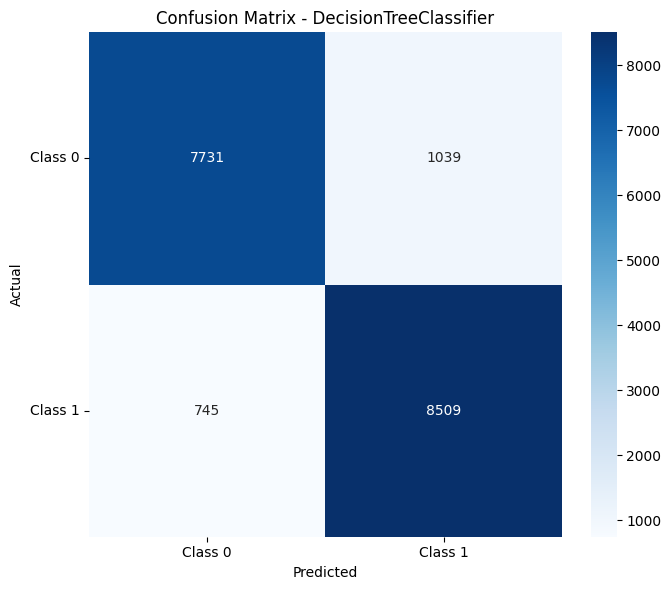

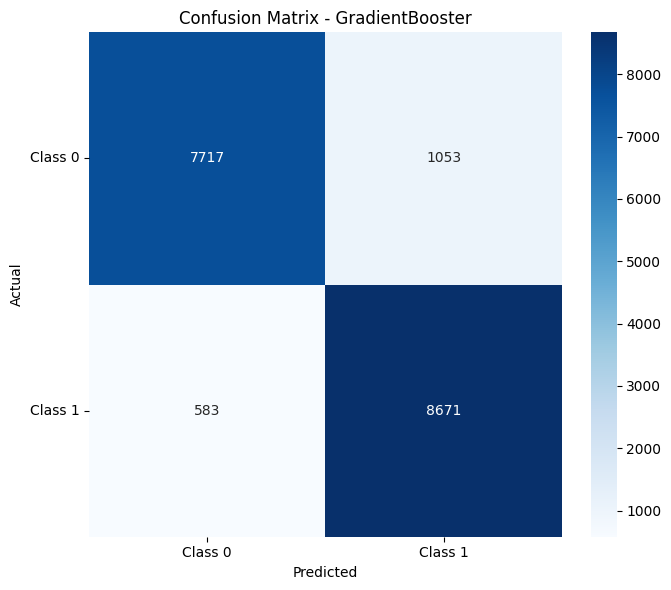

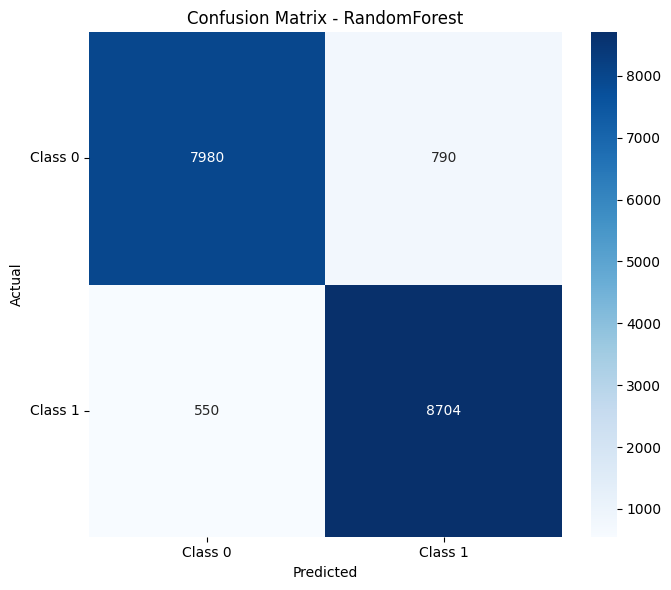

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_val_true = y_test

mechanism_tuples = [
    ('DecisionTreeClassifier', pred_dt),
    ('GradientBooster', pred_gb),
    ('RandomForest', pred_rf)
]

for mechanism, y_val_pred in mechanism_tuples:
    val_cm = confusion_matrix(y_val_true, y_val_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {mechanism}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0.5, 1.5], ["Class 0", "Class 1"])
    plt.yticks([0.5, 1.5], ["Class 0", "Class 1"], rotation=0)
    plt.tight_layout()

    filename = f"/content/drive/MyDrive/AML/Fake-News-Detection/imgs/confusion_matrix_{mechanism}.png"
    plt.savefig(filename)
    plt.show()
